In [1]:

import os
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio
from PIL import Image

from transformers import AutoProcessor, AutoModelForVision2Seq 
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor


In [ ]:
MODEL_NAME = "Qwen/Qwen3-VL-2B-Instruct"
DEVICE = "mps"#"cuda" if torch.cuda.is_available() else "cpu"
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-2B-Instruct", dtype="auto", device_map="auto"
)
model.eval()

Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
 

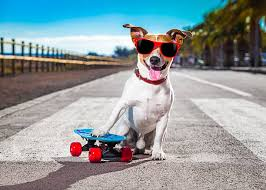

In [ ]:
IMAGE_PATH = "image.png" 

raw_image = Image.open(IMAGE_PATH).convert("RGB")
display(raw_image)

In [5]:

processor = AutoProcessor.from_pretrained(MODEL_NAME)


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [15]:

def generate_caption_with_attentions(image, prompt="Describe this image using at most 8 words."):
    """
    Qwen3-VL-friendly version:
      * builds ALL inputs (includes pixel_values, image_grid_thw, etc.)
      * enables attentions during generate
    Returns:
        caption_text: str
        generated_ids: tensor
        gen_outputs: generation outputs (with attentions if supported)
        inputs: the original input batch (on DEVICE)
    """

    # 1. Build chat messages: PIL image is OK
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    # 2. Let the *processor* handle text + image together
    #    IMPORTANT: return_dict=True so we get a mapping with all needed fields:
    #    input_ids, pixel_values, image_grid_thw, attention_mask, etc.
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

    # some models add token_type_ids; Qwen3-VL example removes it
    inputs.pop("token_type_ids", None)

    # 3. Move everything to DEVICE
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # 4. Generate with attentions
    with torch.no_grad():
        gen_outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            output_attentions=True,
            return_dict_in_generate=True,
        )

    # 5. Sequences & decoding
    generated_ids = gen_outputs.sequences  # [batch, seq_len]
    # If you want just the first sample:
    generated_ids_first = generated_ids[0]

    # Trim off the prompt part if you only want the newly generated text
    # (this is how the docs do it)
    gen_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]

    caption_text = processor.batch_decode(
        gen_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return caption_text, generated_ids_first, gen_outputs, inputs

caption, generated_ids, outputs, inputs = generate_caption_with_attentions(raw_image)
print(caption)

Dog with sunglasses on skateboard.


In [ ]:
def extract_cross_attention_per_step(outputs, inputs):
    """
    Qwen3-VL returns only decoder self-attention.

    Image tokens appear FIRST in the input sequence.
    So cross-attention = attention[:, :, last_token, :image_token_count]
    """

    if outputs.decoder_attentions is None:
        raise RuntimeError("decoder_attentions was not returned.")
    
    decoder_att = outputs.decoder_attentions  # list[num_steps] of [layer][B,h,T,T]

    # number of image tokens
    # pixel_values shape = [1, C, Hf, Wf] → Hf*Wf = token length
    image_token_count = inputs["pixel_values"].shape[-1]

    cross_per_step = []

    for step_att_per_layer in decoder_att:
        # choose last layer
        att = step_att_per_layer[-1]  # [B, nH, tgt_len, src_len]
        att = att[0]  # batch=1 → [nH, T, T]

        att_last_token = att[:, -1, :]  # [nH, T]

        # slice only image token range
        att_image = att_last_token[:, :image_token_count]  # [nH, img_tokens]

        # avg heads
        att_mean = att_image.mean(dim=0).cpu().numpy()

        cross_per_step.append(att_mean)

    return cross_per_step
attn = extract_cross_attention_per_step(outputs, inputs)


AttributeError: 'GenerateDecoderOnlyOutput' object has no attribute 'decoder_attentions'

In [18]:
outputs

GenerateDecoderOnlyOutput(sequences=tensor([[151644,    872,    198, 151652, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151653,  74785,    419,   2168,   1667,    518,   1429,
            220,     23,   4244,     13, 151645,    198, 151644,  77091,    198,
          48940,    448,  59369,    389,  97982,     13, 151645]],
       device='mps:0'), scores=None, logits=None, attentions=(None, None, None, None, N